In [8]:
import pandas as pd
import re
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

fig = go.Figure()

def plot_osobnik(filename, legend, fig=fig, osobnik_id=None, offset=False):
    df = pd.read_csv(filename)
    df["score"] = df["score"].apply(parse_tensor)
    for (osobnik), group in df.groupby(["osobnik"]):
        if osobnik_id is not None and osobnik[0] != osobnik_id:
            continue
        epoka = group["epoch"]
        if offset:
            epoka += 1
        fig.add_trace(go.Scatter(
            x=epoka,
            y=group["score"],
            mode="lines+markers",
            name=f"{legend}_{ osobnik[0]}"
        ))

# plot_osobnik('/home/piotr/repos/magisterka/outputs/run_20260514T165724/epochs.csv', 'PIOTRFORMER, osobnik6')
# plot_osobnik('/home/piotr/repos/magisterka/outputs/BASE_GENOME_CGP2D/epochs.csv', "BASELINE TRANSFORMER")
#plot_osobnik('/home/piotr/repos/magisterka/outputs/run_20260515T204720_FINAL_VERSION_MEDIUM_EPOCH/epochs.csv', "CHILDREN")
# plot_osobnik('/home/piotr/repos/magisterka/outputs/FULL_RUN_original_genomes_GCP/epochs.csv', "ORYGINALNY TRANSFORMER", osobnik_id=0, offset=True)
# plot_osobnik('/home/piotr/repos/magisterka/outputs/run_20260525T210903_chromosome_679/epochs.csv', "WYEWOLUOWANY KANDYDAT")
# plot_osobnik('/home/piotr/repos/magisterka/outputs/run_20260526T072306/epochs.csv', "PIERWSZY RODZIC")
plot_osobnik('/home/piotr/repos/magisterka/outputs/run_20260616T232231/epochs.csv', "exploration")
fig.update_layout(
    title="wyniki",
    xaxis_title="Epoch",
    yaxis_title="Score"
)
fig.show(config={"scrollZoom": True})
fig.write_html("wyniczki.html", config={"scrollZoom": True})

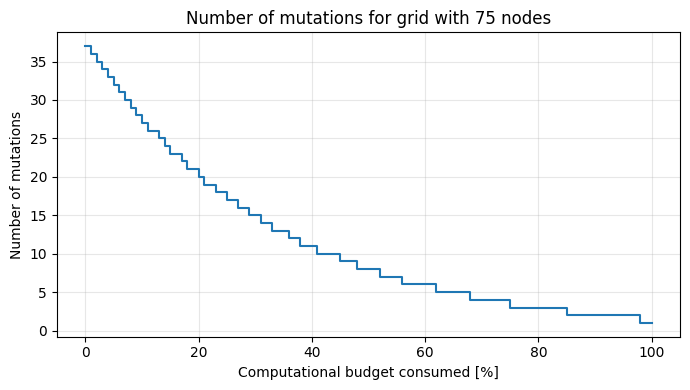

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt


def mutation_count(genome_length, consumed_budget_ratio, k=3):
    remaining_ratio = 1.0 - consumed_budget_ratio

    return max(
        1,
        math.floor(
            0.5
            * (genome_length - 1)
            * math.exp(-k * (1 - remaining_ratio))
        )
    )


# CGP grid
columns = 15
rows = 5

# +1 for the output gene
genome_length = columns * rows + 1

consumed = np.linspace(0.0, 1.0, 101)

mutations = [
    mutation_count(genome_length, x, k=3)
    for x in consumed
]

plt.figure(figsize=(7, 4))
plt.step(consumed * 100, mutations, where="post")

plt.xlabel("Computational budget consumed [%]")
plt.ylabel("Number of mutations")
plt.title("Number of mutations for grid with 75 nodes")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("mutation_schedule.pdf", bbox_inches="tight")
plt.savefig("mutation_schedule.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
import pandas as pd
import re
import plotly.graph_objects as go

def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

df = pd.read_csv("/home/piotr/repos/magisterka/outputs/run_20260501T223303/epochs.csv")
df["score"] = df["score"].apply(parse_tensor)

fig = go.Figure()

osobniki = sorted(df["osobnik"].unique())

# przypisz grupy: 0,1,2,3 (po 5 elementów)
group_map = {os: i // 5 for i, os in enumerate(osobniki)}

colors = ["red", "blue", "green", "orange"]

for osobnik, group in df.groupby("osobnik"):
    g = group_map[osobnik]
    color = colors[g]

    fig.add_trace(go.Scatter(
        x=group["epoch"],
        y=group["score"],
        mode="lines+markers",
        line=dict(color=color),
        marker=dict(color=color),
        name=f"osobnik {osobnik} (g{g})"
    ))

fig.update_layout(
    title="4 grupy po 5 osobników",
    xaxis_title="Epoch",
    yaxis_title="Score"
)

fig.show(config={"scrollZoom": True})
fig.write_html("wyniki.html", config={"scrollZoom": True})

In [ ]:
import pandas as pd
import re
import plotly.graph_objects as go
from plotly.subplots import make_subplots



def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

df_short_genes = pd.read_csv("/home/piotr/repos/magisterka/outputs/100_epok_0.1_epoki_10_oryginalnych_genomow/epochs.csv")
df_short_genes["score"] = df_short_genes["score"].apply(parse_tensor)
df_short_genes["source"] = "long genomes (7 +/- 3)"

df_long_genes = pd.read_csv("/home/piotr/repos/magisterka/outputs/100_epok_0.1_epoki_10_nowych_dlugich_genomow/epochs.csv")
df_long_genes["score"] = df_long_genes["score"].apply(parse_tensor)
df_long_genes["source"] = "long genomes (25 +/- 3)"


fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Krótki genom (7 +/- 3)", "Długi genom (25 +/- 3)"))
for (osobnik, source), group in df_short_genes.groupby(["osobnik", "source"]):
    fig.add_trace(go.Scatter(
        x=group["epoch"],
        y=group["score"],
        mode="lines+markers",
        name=f"osobnik {osobnik} ({source})"
    ),
    row=1, col=1)

for (osobnik, source), group in df_long_genes.groupby(["osobnik", "source"]):
    fig.add_trace(go.Scatter(
        x=group["epoch"],
        y=group["score"],
        mode="lines+markers",
        name=f"osobnik {osobnik} ({source})"
    ),
    row=2, col=1)

fig.update_layout(
    title="Krótki vs długi genom",
    xaxis_title="epoka",
    yaxis_title="score",
)
fig.show(config={"scrollZoom": True})
fig.write_html("wykres.html" ,config={"scrollZoom": True})

In [13]:
import pandas as pd
import re
import plotly.graph_objects as go

# --- helper: wyciąga float z "tensor(4.9219)"
def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

# --- wczytanie danych
df1 = pd.read_csv("/home/piotr/repos/magisterka/outputs/100_epok_0.1_epoki_10_oryginalnych_genomow/epochs.csv")
df2 = pd.read_csv("/home/piotr/repos/magisterka/outputs/csv/vrp10_20_epochs_epoch_128000.csv")

# --- czyszczenie score
df1["score"] = df1["score"].apply(parse_tensor)
df2["score"] = df2["score"].apply(parse_tensor)

# --- oznaczamy źródło (żeby rozróżnić linie)
df1["source"] = "100 epok"
df2["source"] = "20 epok"

# --- łączymy
df = pd.concat([df1, df2], ignore_index=True)

# --- plot
fig = go.Figure()

for (osobnik, source), group in df.groupby(["osobnik", "source"]):
    fig.add_trace(go.Scatter(
        x=group["epoch"],
        y=group["score"],
        mode="lines+markers",
        name=f"osobnik {osobnik} ({source})"
    ))

fig.update_layout(
    title="20 vs 100 epok, stabilność",
    xaxis_title="Epoch",
    yaxis_title="Score"
)

fig.show()
fig.write_html("20vs100_epok_stabilnosc.html" ,config={"scrollZoom": True})

In [ ]:
import pandas as pd
import re
import plotly.graph_objects as go

# --- helper: wyciąga float z "tensor(4.9219)"
def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

# --- wczytanie danych
df_children = pd.read_csv("/home/piotr/repos/magisterka/outputs/PIERWSZY_RUN_EWOLUCJI/children.csv")
df_children["score_clean"] = df_children["score"].apply(parse_tensor)
osobniki_id_best = df_children[df_children['score_clean'] < df_children['score_clean'].cummin().shift(1, fill_value=float('inf'))]['osobnik_id'].tolist()


df_epochs = pd.read_csv("/home/piotr/repos/magisterka/outputs/PIERWSZY_RUN_EWOLUCJI/epochs.csv")
df_epochs["score"] = df_epochs["score"].apply(parse_tensor)
df_filtered = df_epochs[df_epochs['osobnik'].isin(osobniki_id_best)]
n_osobnikow = len(osobniki_id_best)
fig = go.Figure()

for i, os_id in enumerate(osobniki_id_best):
    data = df_filtered[df_filtered['osobnik'] == os_id]
    fig.add_trace(
        go.Scatter(
            x=data['epoch'], 
            y=data['score'],
            mode='lines+markers',
            name=f"osobnik {os_id}"
        )
    )


fig.update_layout(
    yaxis=dict(range=[0, df_filtered['score'].max() * 1.1]), # od 0 do max + 10% zapasu
    title_text="Historia ewolucji",
    showlegend=True,
    template="plotly_white"
)

fig.show()
fig.write_html("historia_ewolucji_1.html" ,config={"scrollZoom": True})


In [ ]:
import pandas as pd
import re
import plotly.graph_objects as go

# --- helper: wyciąga float z "tensor(4.9219)"
def parse_tensor(x):
    if isinstance(x, str):
        m = re.search(r"tensor\(([-+]?\d*\.?\d+)\)", x)
        if m:
            return float(m.group(1))
    return float(x)

df = pd.read_csv("/home/piotr/repos/magisterka/outputs/badanie_stabilnosci_1_osobnik_10_runow/epochs.csv")

df["score"] = df["score"].apply(parse_tensor)


# --- plot
fig = go.Figure()
for osobnik, group in df.groupby(["osobnik"]):
    fig.add_trace(go.Scatter(
        x=group["epoch"],
        y=group["score"],
        mode="lines+markers",
        name=f"run {osobnik}"
    ))

fig.update_layout(
    title="1 osobnik, 10 runów",
    xaxis_title="Epoch",
    yaxis_title="Score"
)

fig.show()
fig.write_html("1_osobnik_stabilnosc.html" ,config={"scrollZoom": True})